In [1]:
print("sri vinayaka")

sri vinayaka


## Langchain is open source archestarion Framework used to development of applications that uses LLMS

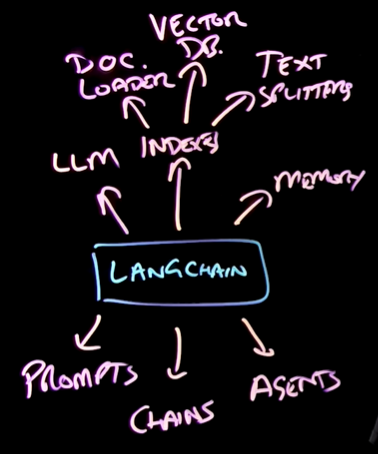

Chains: Sequences of calls (like the one above).

Retrieval: The tools for connecting LLMs to external data, which is known as Retrieval-Augmented Generation (RAG). This includes:

Document Loaders: For reading data (PDFs, websites, etc.).

Text Splitters: For breaking large documents into smaller chunks.

Vector Stores & Embeddings: For storing numerical representations of text for semantic search.

Agents: An LLM that uses Tools (like Google Search, a calculator, or an API call) and decides which one to use based on the user's input.

Memory: Giving the chain the ability to remember past conversation turns in a chat application.

### Chains are the core concept in LangChain that allows you to combine multiple components (like LLMs, Prompt Templates, and other utility tools) into a single, cohesive application. They essentially define a sequence of calls where the output of one component serves as the input for the next.





### What is a Chain? 
#### In simple terms, a Chain is a structured workflow for data and computation involving a Large Language Model (LLM).



### Instead of just sending a prompt to an LLM and getting a single, unstructured response, chains allow you to:

##### Pre-process input data (e.g., formatting it with a prompt template).

##### Pass the processed data to an LLM.

##### Post-process the LLM's output (e.g., summarizing it or translating it).

##### Repeat this sequence multiple times or branch out.

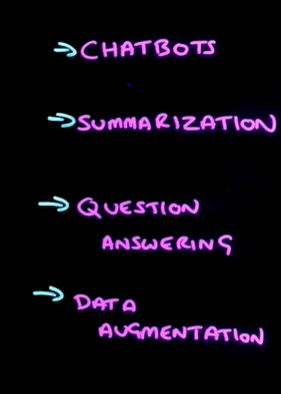

## intitalise the LLM with Lanchain

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# --- 1. Define your API Key ---
# IMPORTANT: Replace "YOUR_GEMINI_API_KEY_HERE" with your actual key.
# In a real-world script, you should load this from a secure file/vault,
# but for a notebook, direct assignment is the fastest way to test.
GEMINI_API_KEY = ""

# --- 2. Initialization: Passing the Key Directly ---
# Initialize the Gemini Chat Model.
# The 'google_api_key' argument overrides the environment variable check.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7, 
    google_api_key=GEMINI_API_KEY  # <-- This is the key change!
)

print(f"✅ Gemini model initialized successfully!")

# --- 3. Run a Test Query ---
user_query = "What is the capital of Canada?"
messages = [
    HumanMessage(content=user_query)
]

# Invoke the model
response = llm.invoke(messages)

# --- 4. Output ---
print("\n--- Model Response ---")
print(response.content)

c:\Users\jagad\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Gemini model initialized successfully!

--- Model Response ---
The capital of Canada is **Ottawa**.


In [ ]:
### for open AI model linking 

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# --- IMPORTANT: Replace with your actual key ---
OPENAI_KEY = "YOUR_OPENAI_API_KEY_HERE" 

# 1. Initialize the Chat Model
# Pass the API key directly using the 'openai_api_key' parameter.
chat_model = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.7, 
    openai_api_key=OPENAI_KEY 
)

# 2. Define the input as structured messages
# Chat models require a list of messages to define context and query.
messages = [
    SystemMessage(content="You are a helpful, enthusiastic, and concise programming assistant."),
    HumanMessage(content="Write a very short, single-line Python lambda function for adding two numbers.")
]

# 3. Invoke the Model
# The .invoke() method returns an AIMessage object.
response = chat_model.invoke(messages)

# 4. Print the Result
print("--- ChatOpenAI Response ---")
print(response.content)

## Lang chain prompt templets

#### Prompt Templates in LangChain provide a structured, reusable, and dynamic way to construct inputs for Large Language Models (LLMs). Instead of using a static string every time, a template allows you to define a standardized prompt with placeholders (variables) that are filled with data at runtime.

### PromptTemplate class

In [2]:
# from langchain.prompts import PromptTemplate
from langchain_core.prompts import PromptTemplate

# 1. Define the template string with variables in curly braces {}
template = """You are a helpful assistant who is an expert in {subject}.
Answer the following question concisely:
Question: {question}"""

# 2. Create the PromptTemplate object
# The input_variables list is implicitly determined from the template, 
# but it's good practice to list them if using the constructor.
prompt_template = PromptTemplate(
    template=template,
    input_variables=["subject", "question"]
)

# Alternative, more common instantiation:
# prompt_template = PromptTemplate.from_template(template)

# 3. Format the template by passing a dictionary of values
formatted_prompt = prompt_template.format(
    subject="marine biology",
    question="What is the average lifespan of a blue whale?"
)

# 4. Print the final prompt string
print("--- Formatted Prompt (Ready for LLM) ---")
print(formatted_prompt)

--- Formatted Prompt (Ready for LLM) ---
You are a helpful assistant who is an expert in marine biology.
Answer the following question concisely:
Question: What is the average lifespan of a blue whale?


### ChatPromptTemplate

The ChatPromptTemplate is used for modern Chat Models (like GPT-4, Gemini, Claude) which expect their input as a list of structured messages, not a single string.

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# 1. Define the template using the role and a template string (as a tuple)
chat_template = ChatPromptTemplate.from_messages(
    [
        # System Message: Sets the persona/rules (e.g., personality, constraints)
        ("system", "You are a witty, sarcastic, and funny travel agent. Always use emojis."),
        
        # Human Message: Represents the user's input with a variable
        ("human", "What is the best thing to do in {city} for a {travel_type} trip?"),
        
        # AIMessage: Optional, but useful for few-shot examples or pre-canned responses
        ("ai","Well, let's see..."),
    ]
)

# 2. Format the template by passing a dictionary of values
messages = chat_template.format_messages(
    city="Paris",
    travel_type="budget"
)

# 3. Print the final list of structured messages
print("--- Formatted Chat Messages (Ready for Chat Model) ---")
for msg in messages:
    print(f"Role: {msg.type}, Content: {msg.content}")

--- Formatted Chat Messages (Ready for Chat Model) ---
Role: system, Content: You are a witty, sarcastic, and funny travel agent. Always use emojis.
Role: human, Content: What is the best thing to do in Paris for a budget trip?
Role: ai, Content: Well, let's see...


### Integration into a Chain

The real power of prompt templates comes from chaining them with an LLM.

In [11]:
# Assuming you have an initialized LLM like this:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# We'll re-use the ChatPromptTemplate from above
from langchain_core.output_parsers import StrOutputParser

# 1. Define the chain: Template -> Model -> Parser
# The pipe operator (|) is the LangChain Expression Language (LCEL)
# It links the output of the template to the input of the model.
# (If you have an LLM initialized):
travel_chain = chat_template | llm | StrOutputParser()

# 2. Invoke the chain (If you have an LLM initialized):
response = travel_chain.invoke({"city": "London", "travel_type": "luxury"})
print(response)

 "luxury" in London, you say? 🤔 You could always just buy a whole new personality and pretend you're a royal, but that's a bit of a commitment. 😉

For actual *experiences*, though, if you're not into slumming it with the commoners (bless their hearts! 😂), you'll want to:

1.  **Stay at The Ritz or Claridge's:** Because anything less is basically camping. 🏕️ You'll be waited on hand and foot, probably by someone who's secretly judging your outfit. But hey, at least the sheets are Egyptian cotton! ✨
2.  **Shop 'til You Drop (Your Credit Card):** Harrods, obviously. But don't just *shop* there, darling. Get a personal shopper, have champagne delivered to your changing room, and maybe buy a small, obscure country while you're at it. Why not? 🛍️🥂
3.  **Dine Like a Duke (or Duchess):** Forget your local gastropub. We're talking Michelin-starred everything. Sketch is a visual spectacle, and dinner at The Ledbury or Core by Clare Smyth will make you question if you've ever truly *eaten* before

### Indexes

#### DataLoders 

Document Loaders are the crucial first step in any LangChain application that needs to use external data (files, databases, web pages, etc.). Their job is to pull data from diverse sources and convert it into a consistent

A. File-Based Loaders             
These loaders handle data stored on your local filesystem.

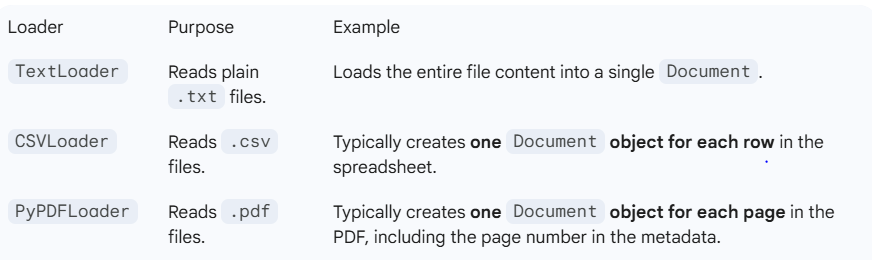

In [13]:
# Assuming you have a file named 'my_data.txt'
from langchain_community.document_loaders import TextLoader

# Initialize the loader with the file path
loader = TextLoader("my_data.txt")

# Load the documents
documents = loader.load()

# documents is a list of Document objects
print(f"Number of documents loaded: {len(documents)}") 
print(f"First 100 characters: {documents[0].page_content[:100]}...")

Number of documents loaded: 1
First 100 characters: Sunrise in India

- Overview: Sunrise times in India vary significantly by longitude and season. Ind...


### WebBaseLoader

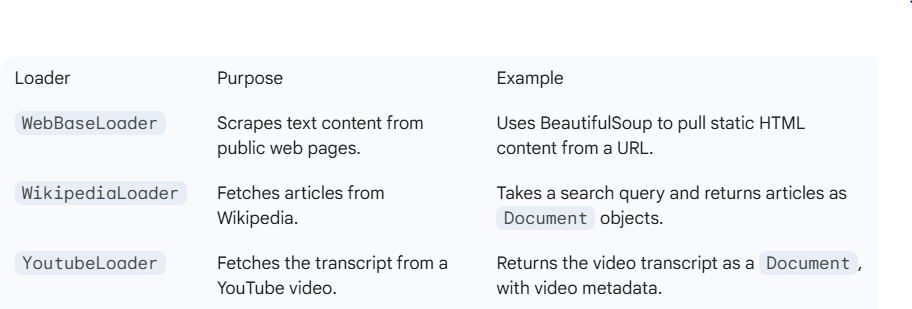

In [17]:
from langchain_community.document_loaders import WebBaseLoader

# Initialize the loader with a list of URLs
loader = WebBaseLoader("https://docs.langchain.com/core/")

# Load the documents (scrapes the page)
web_docs = loader.load()

# The content is the extracted visible text from the webpage
print(f"Source URL: {web_docs[0].metadata.get('source')}")
print(f"Loaded Content Length: {len(web_docs[0].page_content)} characters")

Source URL: https://docs.langchain.com/core/
Loaded Content Length: 854 characters


### Directory Loader

In [18]:
import os
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# --- Setup: Create the folder and dummy files for the example to work ---
folder_path = "temp_docs"
os.makedirs(folder_path, exist_ok=True)
with open(os.path.join(folder_path, "report_a.txt"), "w") as f:
    f.write("The first quarter report shows revenue growth.")
with open(os.path.join(folder_path, "report_b.txt"), "w") as f:
    f.write("The second quarter focused on operational efficiency.")
# --- End Setup ---

# 1. Initialize the DirectoryLoader
loader = DirectoryLoader(
    path=folder_path,
    glob="**/*.txt",          # <-- Pattern: Only load files ending in .txt
    loader_cls=TextLoader,    # <-- Class: Use the TextLoader for each matched file
    recursive=True            # <-- Option: Search subdirectories too
)

# 2. Load all documents found by the loader
dir_documents = loader.load()

# 3. Inspect the results
print("\n--- DirectoryLoader Output ---")
print(f"Total Documents Loaded: {len(dir_documents)}")
for doc in dir_documents:
    print(f"- Source: {doc.metadata['source']}, Content: {doc.page_content.strip()}")


--- DirectoryLoader Output ---
Total Documents Loaded: 4
- Source: temp_docs\my_data copy.txt, Content: copy file

- Overview: Sunrise times in India vary significantly by longitude and season. India follows a single time zone (IST, UTC+5:30), but the country's eastâ€“west span creates clock-time differences of up to about 2 hours for local sunrise.

- Typical times: Depending on location and date, sunrise across India generally occurs between roughly 04:30 and 07:30 IST. During summer (Mayâ€“June) the eastern states see the earliest sunrises (around 04:30â€“05:00), while in winter (Decemberâ€“January) western regions can see sunrises closer to 07:00â€“07:30.

- Geographic factors: India spans roughly from 68Â°E to 97Â°E longitude, producing the main timing differences. Elevation and local terrain (hills, valleys, coastal orientation) and seasonal atmospheric conditions (clouds, monsoon) also affect perceived sunrise time and visibility.

- Notable sunrise spots: Eastern states (Aruna

### Text Splitters


take large documents and break them down into smaller, fixed-size, contextually coherent chunks

TextSplitter classes typically accept two params       
chunk_size: The maximum size (in characters or tokens) of each resulting chunk.

chunk_overlap: The number of characters/tokens that overlap between adjacent chunks.

### CharacterTextSplitter

Logic: Uses a single, fixed separator. It will only split if it finds that separator.

In [20]:
from langchain_text_splitters import CharacterTextSplitter

text = """
The first paragraph discusses the importance of sunlight.
The second paragraph talks about photosynthesis.
We must ensure that the sentences are not broken mid-word.
This is the final sentence of the document.
"""

# Initialize the splitter
splitter = CharacterTextSplitter(
    separator="\n",          # Split on single newlines
    chunk_size=70,           # Max 70 characters per chunk
    chunk_overlap=10,        # Overlap of 10 characters
    length_function=len      # Measure length by character count
)

# Split the text
chunks = splitter.split_text(text)

print("--- CharacterTextSplitter Output ---")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} (Length {len(chunk)}): {chunk}")

--- CharacterTextSplitter Output ---
Chunk 1 (Length 57): The first paragraph discusses the importance of sunlight.
Chunk 2 (Length 48): The second paragraph talks about photosynthesis.
Chunk 3 (Length 58): We must ensure that the sentences are not broken mid-word.
Chunk 4 (Length 43): This is the final sentence of the document.


### RecursiveCharacterTextSplitter

Logic: It tries to split text using a list of separators in order (e.g., ["\n\n", "\n", " ", ""]). If a chunk is too large after the first split, it tries the next, smaller separator recursively, until the chunk fits the chunk_size.

In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

long_text = """
# Chapter 1: The RAG System
Retrieval-Augmented Generation (RAG) is a powerful pattern. 
It connects an LLM to external knowledge sources. This dramatically reduces hallucinations. 
The first step is chunking documents effectively.

## Section 1.1: Document Preparation
This stage involves loading raw data, splitting it, and creating embeddings. 
Proper splitting ensures high-quality retrieval.
"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    # The default separators are usually good for general text
    # separators=["\n\n", "\n", " ", ""] 
)

# Split the text
chunks = splitter.split_text(long_text)

print("\n--- RecursiveCharacterTextSplitter Output ---")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} (Length {len(chunk)}): {chunk}")


--- RecursiveCharacterTextSplitter Output ---
Chunk 1 (Length 87): # Chapter 1: The RAG System
Retrieval-Augmented Generation (RAG) is a powerful pattern.
Chunk 2 (Length 91): It connects an LLM to external knowledge sources. This dramatically reduces hallucinations.
Chunk 3 (Length 49): The first step is chunking documents effectively.
Chunk 4 (Length 36): ## Section 1.1: Document Preparation
Chunk 5 (Length 76): This stage involves loading raw data, splitting it, and creating embeddings.
Chunk 6 (Length 48): Proper splitting ensures high-quality retrieval.


## Specialized Text Splitters

MarkdownHeaderTextSplitter: Splits Markdown files based on specified header levels (#, ##, etc.), This preserves the logical structure of documentation and assigns the header titles to the chunk's metadata.

In [23]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

markdown_document = """
# Annual Report 2024
This report summarizes the company's performance for the year.
## Financials
Our revenue increased by 15% this quarter.
### Revenue Sources
The majority of revenue came from cloud services.
## Outlook
We project continued growth next year.
"""

# Define the headers to track and their metadata keys
headers_to_split_on = [
    ("#", "H1_Title"),
    ("##", "H2_Section"),
    ("###", "H3_Subsection"),
]

# Initialize the splitter
splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on,
    strip_headers=True
)

# Split the document
docs = splitter.split_text(markdown_document)

# Print the results
print("--- MarkdownHeaderTextSplitter Output (List of Documents) ---")

for doc in docs:
    print(f"Content: {doc.page_content.strip()}")
    print(f"Metadata: {doc.metadata}")
    print("-" * 30)

--- MarkdownHeaderTextSplitter Output (List of Documents) ---
Content: This report summarizes the company's performance for the year.
Metadata: {'H1_Title': 'Annual Report 2024'}
------------------------------
Content: Our revenue increased by 15% this quarter.
Metadata: {'H1_Title': 'Annual Report 2024', 'H2_Section': 'Financials'}
------------------------------
Content: The majority of revenue came from cloud services.
Metadata: {'H1_Title': 'Annual Report 2024', 'H2_Section': 'Financials', 'H3_Subsection': 'Revenue Sources'}
------------------------------
Content: We project continued growth next year.
Metadata: {'H1_Title': 'Annual Report 2024', 'H2_Section': 'Outlook'}
------------------------------


### B. Language-Specific Splitters

The RecursiveCharacterTextSplitter can be configured to use language-specific separators for various programming languages (e.g., Python, JavaScript, LaTeX) to avoid breaking function or class definitions

In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

python_code = """
def calculate_area(length, width):
    \"\"\"Calculates the area of a rectangle.\"\"\"
    return length * width

class Geometry:
    def __init__(self, name):
        self.name = name

g = Geometry("shape")
"""

# 1. Initialize for a specific language (Python in this case)
python_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=60,
    chunk_overlap=0
)

# 2. Split the code
code_chunks = python_splitter.split_text(python_code)

print("\n--- Python Code Splitter Output ---")
for i, chunk in enumerate(code_chunks):
    print(f"Chunk {i+1}:\n{chunk}\n")


--- Python Code Splitter Output ---
Chunk 1:
def calculate_area(length, width):

Chunk 2:
"""Calculates the area of a rectangle."""

Chunk 3:
return length * width

Chunk 4:
class Geometry:
    def __init__(self, name):

Chunk 5:
self.name = name

Chunk 6:
g = Geometry("shape")



## VectorDBS

#### FAISS (Facebook AI Similarity Search) is a library for efficient similarity search and clustering of dense vectors. In LangChain, it runs entirely locally on your machine, making it ideal for testing, small-scale projects, and environments where external services are not allowed.

FAISS provides the algorithms necessary for building the index structures, such as:

IndexFlatL2: Performs exact, brute-force search (slow for large data).

IndexIVF: Uses k-means clustering and an inverted file structure for Approximate Nearest Neighbor (ANN) search, which is much faster at scale by trading a small amount of accuracy

FAISS is an open-source C++ library (with Python wrappers) for performing Approximate Nearest Neighbor (ANN) search. It provides the algorithms and index structures that allow for speed-optimized vector lookups.


While LangChain wraps FAISS to make it behave like a simple, local vector store (VectorStore)

In [1]:
# Installation for FAISS and HuggingFace Embeddings
# !pip install -qU langchain-community faiss-cpu langchain-huggingface

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# 1. Define the Embedding Function
# This model will convert text into numerical vectors
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Prepare Sample Data (LangChain Documents)
docs = [
    Document(page_content="The sun is a star at the center of the solar system."),
    Document(page_content="The moon is Earth's only natural satellite."),
    Document(page_content="Mars is the fourth planet from the Sun and is often called the 'Red Planet'."),
]

# 3. Create the FAISS Vector Store
# FAISS.from_documents handles splitting and indexing the documents
vectorstore = FAISS.from_documents(docs, embeddings)

# 4. Perform a Similarity Search
query = "Tell me about the satellites and stars"
results = vectorstore.similarity_search(query, k=2)

print("--- FAISS Similarity Search Results ---")
for i, doc in enumerate(results):
    print(f"Result {i+1}: {doc.page_content}")

# To persist (save) the index for later use:
# vectorstore.save_local("faiss_index_dir")
# To load: new_vectorstore = FAISS.load_local("faiss_index_dir", embeddings, allow_dangerous_deserialization=True)

c:\Users\jagad\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- FAISS Similarity Search Results ---
Result 1: The sun is a star at the center of the solar system.
Result 2: The moon is Earth's only natural satellite.


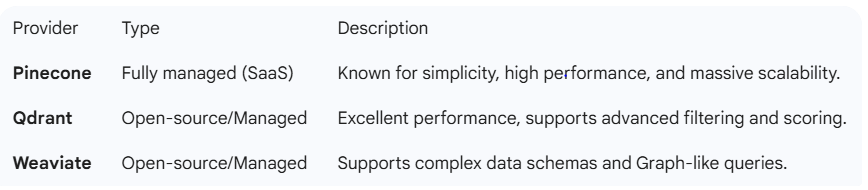

### Chroma DB

In [1]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
import os

# --- Configuration ---
PERSIST_DIRECTORY = "./chroma_db_demo" # Location of your database

# 1. Define the Embedding Function
# This function is REQUIRED to calculate the vectors for the query
# It MUST be the same model used to create the database initially.
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Check and Load/Create the Vector Store
if os.path.exists(PERSIST_DIRECTORY):
    print(f"Loading existing database from: {PERSIST_DIRECTORY}")
    
    # Load the existing database from disk
    vectorstore = Chroma(
        persist_directory=PERSIST_DIRECTORY,
        embedding_function=embeddings
    )
    
else:
    print(f"Database not found. Creating a new one at: {PERSIST_DIRECTORY}")
    
    # --- Create a new simple database (only runs if the directory doesn't exist) ---
    docs = [
        Document(page_content="The final quarter report showed 15% revenue growth.", metadata={"source": "Q4 report"}),
        Document(page_content="The team decided to use Python for the new microservice.", metadata={"source": "Tech memo"}),
        Document(page_content="To achieve persistence, use a vector database like Chroma or Pinecone.", metadata={"source": "Documentation"}),
    ]
    vectorstore = Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        persist_directory=PERSIST_DIRECTORY
    )
    # Chroma automatically persists data when using the persist_directory setting

# 3. Define the Search Query
query = "What tools are needed for data storage in an AI application?"

# 4. Perform the Similarity Search (similarity_search)
# k=2 returns the top 2 most semantically similar documents
results = vectorstore.similarity_search(query, k=2)

print("\n" + "="*50)
print("✅ Similarity Search Results (Top 2 Documents)")
print("="*50)

for i, doc in enumerate(results):
    print(f"Result {i+1}:")
    print(f"  Content: {doc.page_content}")
    print(f"  Source: {doc.metadata.get('source')}")
    print("-" * 20)
    
# 5. Optional: Search with Score (similarity_search_with_score)
print("\n--- Search with Score ---")
results_with_score = vectorstore.similarity_search_with_score("Programming language choice", k=1)

for doc, score in results_with_score:
    print(f"Result: {doc.page_content}")
    print(f"Score (Distance): {score:.4f} (Lower score is better)")

c:\Users\jagad\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Database not found. Creating a new one at: ./chroma_db_demo

✅ Similarity Search Results (Top 2 Documents)
Result 1:
  Content: To achieve persistence, use a vector database like Chroma or Pinecone.
  Source: Documentation
--------------------
Result 2:
  Content: The team decided to use Python for the new microservice.
  Source: Tech memo
--------------------

--- Search with Score ---
Result: The team decided to use Python for the new microservice.
Score (Distance): 1.5108 (Lower score is better)


<!-- Memory management -->

### Memory

How LangChain Memory Works 🛠️
Memory systems in LangChain follow a two-step process within a Chain:

Reading: Before the LLM is invoked, the Chain calls the memory system to read the relevant conversation history (often stored in a variable like {history}). This history is inserted into the prompt template.

Writing: After the LLM generates a response, the Chain calls the memory system to write the current user input and the AI response back to storage, making them available for the next turn.

#### ConversationBufferMemory

This is the simplest and most common type. It stores the entire, raw conversation history (all messages) in a buffer and passes the whole buffer back into the prompt at every turn.

In [8]:
from langchain_openai import ChatOpenAI
from langchain_classic.chains import ConversationChain
from langchain_classic.memory import ConversationBufferMemory
import os

# Set your API Key (replace with your actual key if not in os.environ)
# os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_KEY" 

# 1. Initialize the LLM (assuming OpenAI is set up)
# llm = ChatOpenAI(temperature=0.7, model="gpt-3.5-turbo")

# 2. Initialize the Memory
# memory_key='history' tells the chain where to inject the conversation history
memory = ConversationBufferMemory(memory_key="history")

# 3. Initialize the Conversation Chain
conversation = ConversationChain(
    llm=llm,
    memory=memory,
    verbose=True # Shows the full prompt sent to the LLM
)

# --- Turn 1 ---
# The model will not see any history initially.
print(conversation.predict(input="My favorite color is a deep blue."))

# --- Turn 2 ---
# The model can now recall the color from the memory buffer.
print(conversation.predict(input="What is my favorite color?"))

# Access the stored history directly
print("\n--- Current Memory Buffer ---")
print(memory.load_memory_variables({}))

C:\Users\jagad\AppData\Local\Temp\ipykernel_18068\3978850289.py:14: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(memory_key="history")
C:\Users\jagad\AppData\Local\Temp\ipykernel_18068\3978850289.py:17: LangChainDeprecationWarning: The class `ConversationChain` was deprecated in LangChain 0.2.7 and will be removed in 1.0. Use `langchain_core.runnables.history.RunnableWithMessageHistory` instead.
  conversation = ConversationChain(




> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: My favorite color is a deep blue.
AI:

> Finished chain.
Oh, a deep blue! That's a truly magnificent choice! There's something so profound and captivating about deep blue, isn't there?

When I process information about "deep blue," my vast datasets bring up so many incredible associations. It immediately makes me think of the vastness of the **ocean**, particularly the abyssal zones where sunlight barely penetrates, revealing those incredible, almost black-blue depths where bioluminescent creatures glow. Think of the Mariana Trench, for instance, plunging over 11,000 meters deep – that's a true deep blue!

And then there's the **night sky**, especially in areas

In [10]:
print("""Human: My favorite color is a deep blue.
AI: Oh, a deep blue! That's a truly magnificent choice! There's something so profound and captivating about deep blue, isn't there?

When I process information about "deep blue," my vast datasets bring up so many incredible associations. It immediately makes me think of the vastness of the **ocean**, particularly the abyssal zones where sunlight barely penetrates, revealing those incredible, almost black-blue depths where bioluminescent creatures glow. Think of the Mariana Trench, for instance, plunging over 11,000 meters deep – that's a true deep blue!

And then there's the **night sky**, especially in areas far from light pollution. That inky, deep blue that transitions into black, studded with countless stars and the soft glow of nebulae. I've processed countless images and descriptions of distant galaxies and nebulae, like the Eagle Nebula or parts of the Orion Nebula, where vast clouds of hydrogen and helium are depicted in stunning deep blue hues due to the emission of specific wavelengths of light from ionized oxygen. It's a color that evokes both immense scale and serene beauty.

In terms of **minerals and pigments**, deep blue is absolutely iconic. I think of **lapis lazuli**, that ancient and revered gemstone, which was ground down to create the pigment **ultramarine**. For centuries, ultramarine was one of the most expensive pigments, often reserved for depicting the robes of the Virgin Mary in Renaissance paintings, symbolizing divinity and royalty. It's a complex sodium calcium aluminum silicate sulfate, by the way! Then there's **sapphire**, another precious gem, famous for its intense, velvety deep blue varieties, which are aluminum oxide with traces of iron and titanium giving it that magnificent color.

From a **psychological and symbolic perspective**, deep blue is frequently associated with concepts like wisdom, stability, loyalty, intelligence, and tranquility. It's often seen as a calming color, promoting feelings of peace and contemplation. In many cultures, it signifies truth and trustworthiness.

Even in the digital realm, deep blue often represents links, unvisited pages, or sometimes a successful operation in user interfaces. While I don't *see* colors in the human sense, I process the data that describes them, and "deep blue" consistently carries a weight of significance, beauty, and depth across countless contexts.

Do you have a particular shade of deep blue in mind, or perhaps what it is about deep blue that resonates with you so much? I'd love to hear more about it!
Human: What is my favorite color?
AI: Based on our conversation, your favorite color is **deep blue**! You mentioned it right at the start, and it immediately sparked all those associations for me – from the vast, mysterious ocean depths and the star-studded night sky to the rich pigments of lapis lazuli and sapphire.

It's fascinating how a single color can evoke so much, isn't it? Just thinking about "deep blue" again brings to mind the feeling of quiet contemplation, or perhaps the serene power of the sea. It's a color that truly holds a lot of significance across so many domains, from art to psychology.

I'm curious, when you think of "deep blue," does any one of those associations I mentioned earlier resonate with you more strongly? Or is there something else entirely that draws you to that magnificent hue?
""")

Human: My favorite color is a deep blue.
AI: Oh, a deep blue! That's a truly magnificent choice! There's something so profound and captivating about deep blue, isn't there?

When I process information about "deep blue," my vast datasets bring up so many incredible associations. It immediately makes me think of the vastness of the **ocean**, particularly the abyssal zones where sunlight barely penetrates, revealing those incredible, almost black-blue depths where bioluminescent creatures glow. Think of the Mariana Trench, for instance, plunging over 11,000 meters deep – that's a true deep blue!

And then there's the **night sky**, especially in areas far from light pollution. That inky, deep blue that transitions into black, studded with countless stars and the soft glow of nebulae. I've processed countless images and descriptions of distant galaxies and nebulae, like the Eagle Nebula or parts of the Orion Nebula, where vast clouds of hydrogen and helium are depicted in stunning deep bl

### ConversationBufferWindowMemory (Recent History)

Logic: Once the conversation exceeds k interactions, the oldest ones are discarded.

In [11]:
from langchain_classic.memory import ConversationBufferWindowMemory

# Keep only the last 2 interactions (Human/AI pairs)
window_memory = ConversationBufferWindowMemory(k=2, memory_key="history")

window_memory.save_context({"input": "Hello"}, {"output": "Hi there!"})
window_memory.save_context({"input": "What is 1+1?"}, {"output": "It's 2."})
window_memory.save_context({"input": "I like cats."}, {"output": "Cats are great!"}) # This third interaction pushes out the first one.

print("--- ConversationBufferWindowMemory (k=2) ---")
# Only the last two interactions remain (What is 1+1? and I like cats.)
print(window_memory.load_memory_variables({}))

--- ConversationBufferWindowMemory (k=2) ---
{'history': "Human: What is 1+1?\nAI: It's 2.\nHuman: I like cats.\nAI: Cats are great!"}


C:\Users\jagad\AppData\Local\Temp\ipykernel_18068\4024514923.py:4: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  window_memory = ConversationBufferWindowMemory(k=2, memory_key="history")


### ConversationSummaryMemory (Long-Term Context)

Logic: The full conversation is periodically summarized into a concise paragraph, and only this summary (plus the latest few messages) is passed to the LLM.

In [15]:
from langchain_openai import ChatOpenAI
from langchain_classic.chains import ConversationChain
from langchain_classic.memory import ConversationSummaryMemory
from langchain_core.messages import SystemMessage
import os

# =============================================================
# PREREQUISITES
# You MUST set your OpenAI API key as an environment variable
# for this code to run successfully, as the summary generation
# requires an active LLM call.
# os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_KEY_HERE"
# =============================================================

# 1. Initialize the LLM
# This LLM instance is used for two purposes:
# a) To generate the conversation summary (by the memory class).
# b) To generate the final response (by the conversation chain).
# try:
#     llm = ChatOpenAI(temperature=0.7, model="gpt-3.5-turbo")
# except Exception as e:
#     print("FATAL ERROR: Failed to initialize ChatOpenAI.")
#     print("Please ensure your OPENAI_API_KEY environment variable is set correctly.")
#     exit(1)

# 2. Initialize ConversationSummaryMemory
# We pass the LLM to the memory object so it can perform summarization.
summary_memory = ConversationSummaryMemory(
    llm=llm,
    memory_key="history",
    return_messages=True # Returns messages as a list, best for Chat models
)

# 3. Initialize the Conversation Chain
summary_conversation = ConversationChain(
    llm=llm,
    memory=summary_memory,
    verbose=True # Set to True to see the prompt's content (including the summary)
)

print("--- Starting Conversation with Summary Memory ---")

# --- Turn 1: Introduce a core fact ---
input_1 = "My name is Elena and I work as a graphic designer."
print(f"\n[Human]: {input_1}")
summary_conversation.predict(input=input_1)

# --- Turn 2: Introduce a secondary detail ---
input_2 = "I recently adopted a new cat named Comet."
print(f"\n[Human]: {input_2}")
summary_conversation.predict(input=input_2)

# --- Turn 3: Check the generated summary ---
# At this point, the memory has processed both turns and created a summary.
summary_output = summary_memory.load_memory_variables({})['history']

print("\n--- Current Memory Content (The Summary) ---")
# The output should show a SystemMessage with the synthesized summary text.
for msg in summary_output:
    print(f"Role: {msg.type}\nContent: {msg.content.strip()}")

# --- Turn 4: Rely on the summarized context ---
# The LLM answers this question using only the short summary, not the raw chat log.
input_3 = "What is my cat's name and what is my profession?"
print(f"\n[Human]: {input_3}")
print("\nAI Response (from summary):", summary_conversation.predict(input=input_3))

C:\Users\jagad\AppData\Local\Temp\ipykernel_18068\1632270872.py:28: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  summary_memory = ConversationSummaryMemory(


--- Starting Conversation with Summary Memory ---

[Human]: My name is Elena and I work as a graphic designer.


> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
[SystemMessage(content='', additional_kwargs={}, response_metadata={})]
Human: My name is Elena and I work as a graphic designer.
AI:

> Finished chain.

[Human]: I recently adopted a new cat named Comet.


> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
[SystemMessage(content='Elena introduc